# MNIST utility experiment

Thin notebook for running the same sparse-train augmentation diagnostic on MNIST. Implementation lives in `rankgen_utility_experiment/`.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from rankgen_utility_experiment.experiment import ExperimentConfig, run_on_dataset, summarize, plot_metric_bars, label_metric_columns
from rankgen_utility_experiment.mnist import MnistConfig, make_mnist_dataset, plot_mnist_samples, plot_mnist_umap

k = 8
include_noise_model = False

mnist_config = MnistConfig(
    seed=8,
    train_per_class=30,
    test_per_class=100,
    oracle_per_class=100,
    classes=tuple([4,7,9]), #[4,7,9] [3,5,8]
)

experiment_config = ExperimentConfig(
    seed=mnist_config.seed,
    generated_per_class=100,
    generator_latent_components=4*5,
    smote_neighbors=k,
    transfer_ab_neighbors=k,
    transfer_bc_neighbors=k,
    rf_n_estimators=50,
    rf_max_depth=None,
    rf_min_samples_leaf=4,
    rf_max_features="sqrt",
    rf_max_real_samples=1_000,
    rf_n_jobs=-1,
)

In [2]:
data = make_mnist_dataset(mnist_config)
data.x_train.shape, data.x_test.shape, data.x_oracle.shape

((90, 784), (300, 784), (300, 784))

In [3]:
data, generated, result = run_on_dataset(
    experiment_config,
    data,
    include_noise_model=include_noise_model,
)
label_metric_columns(result).round(4)

,seed,generator,n_generated,quality ↑,utility_gain ↑,utility_augmented_accuracy ↑,baseline_accuracy ↑,similarity_to_train ↓,fid_to_oracle ↓,precision ↑,recall ↑,distinguishability_auc ↓
0,8,SMOTE interpolation,300,0.8700,-0.0400,0.8367,0.8767,3.8930,23.6716,0.9967,0.0067,1.0
1,8,Transferred local differences,300,0.8167,-0.0433,0.8333,0.8767,4.0974,23.8279,0.9400,0.0167,1.0


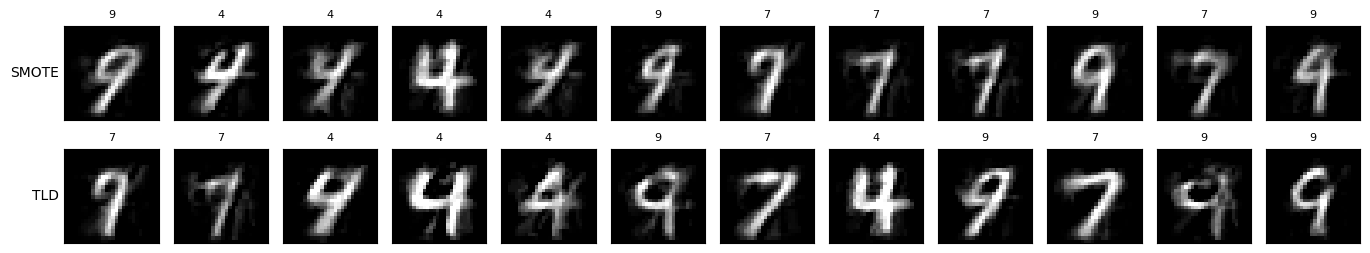

In [4]:
plot_mnist_samples(generated, n_per_generator=12, seed=None);

In [ ]:
plot_mnist_umap(
    data,
    generated,
    max_real=1_000,
    max_generated_per_generator=1_000,
    seed=mnist_config.seed,
);

/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [ ]:
plot_metric_bars(result);

`test_per_class` is the held-out set for downstream accuracy and utility gain. `oracle_per_class` is a separate real sample used for diagnostics such as quality, FID-like distance, precision/recall, and real-vs-generated distinguishability.